# Chapter 11 — Sets and Basic Set Operations

> **Prerequisites:** ch001–ch010
>
> **You will learn:**
> - What a set is and how it differs from a list or array
> - The six basic set operations and their computational implementations
> - How set theory underlies database queries, type systems, and probability
> - Venn diagrams as a tool for reasoning about set relationships
>
> **Environment:** Python 3.x, numpy, matplotlib

## 1. Concept

A **set** is an unordered collection of distinct elements. The two defining properties are:
1. **No order:** $\{1, 2, 3\} = \{3, 1, 2\}$
2. **No duplicates:** $\{1, 1, 2\} = \{1, 2\}$

Sets are the foundation of mathematics. Every mathematical object — numbers, functions, relations, probability spaces — is ultimately defined in terms of sets. For programmers, sets are the natural model for: database columns (unique IDs), type systems (the set of values a type admits), configuration options (a flag is either in the active set or not), and feature spaces in ML (a sample is in the training set or the test set).

The six basic operations:
- **Union** $A \cup B$: everything in A or B (or both)
- **Intersection** $A \cap B$: everything in both A and B  
- **Difference** $A \setminus B$: everything in A but not B
- **Symmetric difference** $A \triangle B$: everything in exactly one of A, B
- **Subset** $A \subseteq B$: every element of A is in B
- **Power set** $\mathcal{P}(A)$: the set of all subsets of A

**Common misconception:** A set and a list are interchangeable.

No. A list has order and permits duplicates. A set has neither. `[1, 2, 3]` and `[3, 2, 1]` are different lists but the same set. Python's `set` type implements sets correctly.

## 2. Intuition & Mental Models

**Physical analogy:** Think of sets as circles drawn on paper — Venn diagrams. The union is the area covered by either circle. The intersection is the overlapping region. The difference is one circle minus the overlap. This spatial intuition is exact: Venn diagrams are a faithful geometric model of set operations.

**Computational analogy:** Sets are what SQL SELECT DISTINCT returns. The UNION, INTERSECT, and EXCEPT (MINUS) operators in SQL are exactly $\cup$, $\cap$, and $\setminus$. If you have used SQL set operations, you already understand set theory — the notation is just different.

Recall from ch009 *(Mathematical Notation for Programmers)*: we catalogued $\cup$, $\cap$, and $\subseteq$ as notation. This chapter operationalizes them.

<>:13: SyntaxWarning: invalid escape sequence '\ '
<>:14: SyntaxWarning: invalid escape sequence '\ '
<>:43: SyntaxWarning: invalid escape sequence '\ '
<>:45: SyntaxWarning: invalid escape sequence '\ '
<>:62: SyntaxWarning: invalid escape sequence '\ '
<>:13: SyntaxWarning: invalid escape sequence '\ '
<>:14: SyntaxWarning: invalid escape sequence '\ '
<>:43: SyntaxWarning: invalid escape sequence '\ '
<>:45: SyntaxWarning: invalid escape sequence '\ '
<>:62: SyntaxWarning: invalid escape sequence '\ '
C:\Users\user\AppData\Local\Temp\ipykernel_17672\3384917011.py:13: SyntaxWarning: invalid escape sequence '\ '
  ('Difference A \ B', 'steelblue', None),
C:\Users\user\AppData\Local\Temp\ipykernel_17672\3384917011.py:14: SyntaxWarning: invalid escape sequence '\ '
  ('Difference B \ A', None, 'coral'),
C:\Users\user\AppData\Local\Temp\ipykernel_17672\3384917011.py:43: SyntaxWarning: invalid escape sequence '\ '
  elif title == 'Difference A \ B' and label == 'A':
C:\Users\user\AppData\

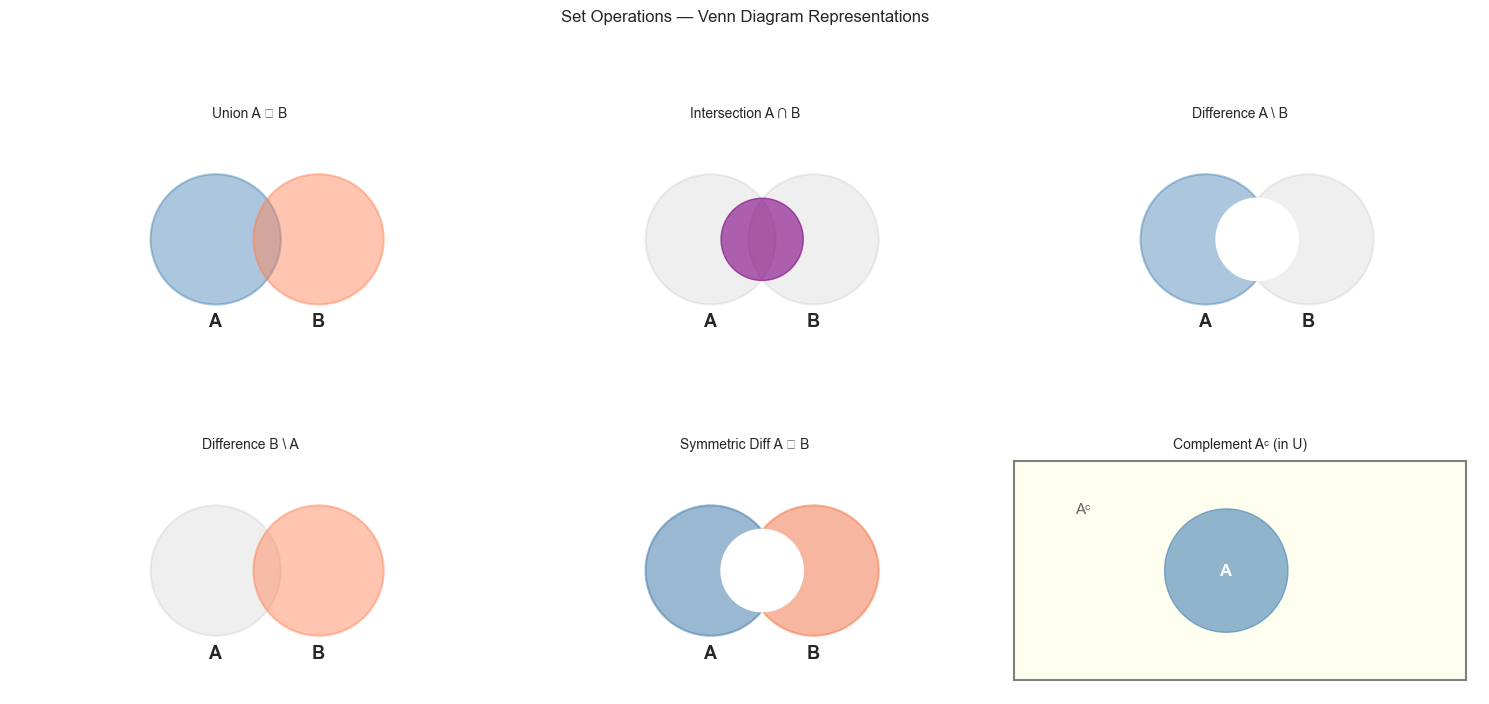

In [1]:
# --- Visualization: Venn diagrams for set operations ---
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
plt.style.use('seaborn-v0_8-whitegrid')

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.patch.set_facecolor('white')

ops = [
    ('Union A ∪ B', 'steelblue', 'steelblue'),
    ('Intersection A ∩ B', None, None),
    ('Difference A \ B', 'steelblue', None),
    ('Difference B \ A', None, 'coral'),
    ('Symmetric Diff A △ B', 'both_excl', None),
    ('Complement Aᶜ (in U)', 'complement', None),
]

for ax, (title, left_col, right_col) in zip(axes.flat, ops):
    ax.set_xlim(-2, 5)
    ax.set_ylim(-1.5, 2)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(title, fontsize=10, pad=4)
    
    if title.startswith('Complement'):
        universe = patches.Rectangle((-1.8, -1.3), 6.6, 3.2, linewidth=1.5,
                                       edgecolor='black', facecolor='lightyellow', alpha=0.5)
        ax.add_patch(universe)
        circle_a = plt.Circle((1.3, 0.3), 0.9, color='steelblue', alpha=0.6)
        ax.add_patch(circle_a)
        ax.text(1.3, 0.3, 'A', ha='center', va='center', fontsize=12, color='white', fontweight='bold')
        ax.text(-0.8, 1.2, 'Aᶜ', ha='center', va='center', fontsize=11, color='dimgray')
        continue
    
    # Left and right circles
    for cx, color, label in [(1.0, 'steelblue', 'A'), (2.5, 'coral', 'B')]:
        fill = None
        if title.startswith('Union'):
            fill = color
        elif title.startswith('Intersection'):
            fill = None
        elif title == 'Difference A \ B' and label == 'A':
            fill = 'steelblue'
        elif title == 'Difference B \ A' and label == 'B':
            fill = 'coral'
        alpha = 0.45 if fill else 0.12
        circle = plt.Circle((cx, 0.3), 0.95, color=fill or 'gray', alpha=alpha, linewidth=1.5, edgecolor='black', fill=True)
        ax.add_patch(circle)
        ax.text(cx, -0.9, label, ha='center', va='center', fontsize=13, fontweight='bold')
    
    # Intersection overlay
    if title.startswith('Intersection'):
        from matplotlib.patches import PathPatch
        circle_i = plt.Circle((1.75, 0.3), 0.6, color='purple', alpha=0.6)
        ax.add_patch(circle_i)
    elif title.startswith('Symmetric'):
        circle_l = plt.Circle((1.0, 0.3), 0.95, color='steelblue', alpha=0.5, linewidth=1.5, edgecolor='black')
        circle_r = plt.Circle((2.5, 0.3), 0.95, color='coral', alpha=0.5, linewidth=1.5, edgecolor='black')
        circle_mid = plt.Circle((1.75, 0.3), 0.6, color='white', alpha=1.0)
        ax.add_patch(circle_l); ax.add_patch(circle_r); ax.add_patch(circle_mid)
    elif title == 'Difference A \ B':
        circle_overlap = plt.Circle((1.75, 0.3), 0.6, color='white', alpha=1.0)
        ax.add_patch(circle_overlap)

plt.suptitle('Set Operations — Venn Diagram Representations', fontsize=12)
plt.tight_layout()
plt.show()

## 4. Mathematical Formulation

**Formal definitions using set-builder notation:**

$$A \cup B = \{x : x \in A \text{ or } x \in B\}$$
$$A \cap B = \{x : x \in A \text{ and } x \in B\}$$
$$A \setminus B = \{x : x \in A \text{ and } x \notin B\}$$
$$A \triangle B = (A \setminus B) \cup (B \setminus A)$$

**Key laws (provable from definitions):**
- Commutativity: $A \cup B = B \cup A$; $A \cap B = B \cap A$
- Associativity: $(A \cup B) \cup C = A \cup (B \cup C)$
- Distributivity: $A \cap (B \cup C) = (A \cap B) \cup (A \cap C)$
- De Morgan: $\overline{A \cup B} = \bar{A} \cap \bar{B}$; $\overline{A \cap B} = \bar{A} \cup \bar{B}$

De Morgan's laws directly correspond to Boolean logic: `not (A or B) == (not A) and (not B)`.

In [2]:
# --- Implementation: Set operations from scratch and verification ---
import numpy as np

class MathSet:
    """
    Immutable mathematical set with standard operations.
    Built on Python frozenset for correctness guarantees.
    """
    def __init__(self, elements):
        self._data = frozenset(elements)
    
    def __contains__(self, x): return x in self._data
    def __len__(self): return len(self._data)
    def __repr__(self): return '{' + ', '.join(str(x) for x in sorted(self._data)) + '}'
    def __eq__(self, other): return self._data == other._data
    
    def union(self, other):        return MathSet(self._data | other._data)
    def intersection(self, other): return MathSet(self._data & other._data)
    def difference(self, other):   return MathSet(self._data - other._data)
    def sym_diff(self, other):     return MathSet(self._data ^ other._data)
    def is_subset(self, other):    return self._data <= other._data
    def power_set(self):
        from itertools import combinations
        elems = list(self._data)
        result = [MathSet([])]
        for r in range(1, len(elems)+1):
            for combo in combinations(elems, r):
                result.append(MathSet(combo))
        return result

A = MathSet([1, 2, 3, 4, 5])
B = MathSet([3, 4, 5, 6, 7])

print(f'A = {A}')
print(f'B = {B}')
print(f'A ∪ B = {A.union(B)}')
print(f'A ∩ B = {A.intersection(B)}')
print(f'A \ B = {A.difference(B)}')
print(f'A △ B = {A.sym_diff(B)}')
print(f'A ⊆ A ∪ B: {A.is_subset(A.union(B))}')

C = MathSet([1, 2, 3])
print(f'\nPower set of {C}:')
for s in C.power_set():
    print(f'  {s}')
print(f'|P(C)| = {len(C.power_set())}  (expected: 2^3 = 8)')

A = {1, 2, 3, 4, 5}
B = {3, 4, 5, 6, 7}
A ∪ B = {1, 2, 3, 4, 5, 6, 7}
A ∩ B = {3, 4, 5}
A \ B = {1, 2}
A △ B = {1, 2, 6, 7}
A ⊆ A ∪ B: True

Power set of {1, 2, 3}:
  {}
  {1}
  {2}
  {3}
  {1, 2}
  {1, 3}
  {2, 3}
  {1, 2, 3}
|P(C)| = 8  (expected: 2^3 = 8)


<>:38: SyntaxWarning: invalid escape sequence '\ '
<>:38: SyntaxWarning: invalid escape sequence '\ '
C:\Users\user\AppData\Local\Temp\ipykernel_17672\2164080353.py:38: SyntaxWarning: invalid escape sequence '\ '
  print(f'A \ B = {A.difference(B)}')


In [3]:
# --- Experiment: Verify set laws computationally ---
import random
random.seed(42)

UNIVERSE = list(range(100))

def random_set():
    return MathSet(random.sample(UNIVERSE, random.randint(5, 40)))

N_TESTS = 1000
laws = {
    'Commutativity (union)': lambda A,B,C: A.union(B) == B.union(A),
    'Commutativity (intersect)': lambda A,B,C: A.intersection(B) == B.intersection(A),
    'Associativity (union)': lambda A,B,C: (A.union(B)).union(C) == A.union(B.union(C)),
    'Distributivity': lambda A,B,C: A.intersection(B.union(C)) == (A.intersection(B)).union(A.intersection(C)),
    'A ∩ A = A': lambda A,B,C: A.intersection(A) == A,
    'A ∪ ∅ = A': lambda A,B,C: A.union(MathSet([])) == A,
}

print('Set law verification (1000 random tests each):')
for name, law in laws.items():
    passed = sum(1 for _ in range(N_TESTS) if law(random_set(), random_set(), random_set()))
    print(f'  {name}: {passed}/{N_TESTS}  {"✓" if passed==N_TESTS else "✗"} ')

Set law verification (1000 random tests each):
  Commutativity (union): 1000/1000  ✓ 
  Commutativity (intersect): 1000/1000  ✓ 
  Associativity (union): 1000/1000  ✓ 
  Distributivity: 1000/1000  ✓ 
  A ∩ A = A: 1000/1000  ✓ 
  A ∪ ∅ = A: 1000/1000  ✓ 


## 7. Exercises

**Easy 1.** For A = {1,2,3,4,5} and B = {3,4,5,6,7}: compute |A ∪ B|, |A ∩ B|, |A \ B| by hand, then verify with Python. Check the inclusion-exclusion formula: |A ∪ B| = |A| + |B| - |A ∩ B|. *(Expected: 7, 3, 2)*

**Easy 2.** Implement De Morgan's law as a test: for random sets A, B in universe U, verify that the complement of (A ∪ B) equals (complement A) ∩ (complement B). *(Expected: law holds in all tests)*

**Medium 1.** A database has tables Customers(id, city), Orders(customer_id, product). Write the set operations that compute: (a) customers who have placed at least one order, (b) customers who have never placed an order, (c) customers who ordered product P but not product Q. Express each as a Python set operation, not as a SQL query.

**Medium 2.** The power set of a set with n elements has 2ⁿ elements. For n=20, the power set has 2²⁰ ≈ 10⁶ elements. For n=30, it has 2³⁰ ≈ 10⁹. What is the largest n for which you can enumerate the power set in Python within 1 second? Find it experimentally.

**Hard.** Implement the inclusion-exclusion principle for n sets: $|A_1 \cup \cdots \cup A_n| = \sum_i |A_i| - \sum_{i<j} |A_i \cap A_j| + \cdots$. Use it to count the number of integers from 1 to 1000 that are divisible by at least one of {2, 3, 5, 7}. Verify against direct counting. *(Challenge: implement for arbitrary n sets using the inclusion-exclusion formula)*

In [4]:
# --- Mini Project: Set-based feature engineering ---
# Represent ML training/test split and feature selection as set operations.
import numpy as np

np.random.seed(42)
N = 200
all_ids = set(range(N))

# Train/test split as set partition
train_ids = set(np.random.choice(N, int(0.8*N), replace=False))
test_ids  = all_ids - train_ids  # A \ B
validation_ids = set(np.random.choice(list(train_ids), int(0.1*N), replace=False))
train_only = train_ids - validation_ids

print('Dataset partitioning via set operations:')
print(f'  Total samples: {len(all_ids)}')
print(f'  Train:         {len(train_only)}')
print(f'  Validation:    {len(validation_ids)}')
print(f'  Test:          {len(test_ids)}')
print(f'  Sum:           {len(train_only)+len(validation_ids)+len(test_ids)}')
print(f'  Disjoint (no overlap): {len(train_only & validation_ids & test_ids) == 0}')
print(f'  Cover (union = all):   {train_only | validation_ids | test_ids == all_ids}')

Dataset partitioning via set operations:
  Total samples: 200
  Train:         140
  Validation:    20
  Test:          40
  Sum:           200
  Disjoint (no overlap): True
  Cover (union = all):   True


## 9. Chapter Summary & Connections

- Sets are unordered collections of distinct elements — no duplicates, no order
- The six operations (union, intersection, difference, symmetric difference, subset, power set) are the building blocks of all further set theory
- De Morgan's laws connect set operations to Boolean logic — exactly the same duality
- Set operations underlie SQL queries, type systems, probability spaces, and ML dataset management

**Forward:** Sets are the foundation of ch241 — Sample Spaces (a probability space is a set with a measure). The subset relation underlies ch137 — Subspaces in linear algebra. Database-style set operations reappear in ch271 — Data and Measurement.

**Backward:** This chapter operationalizes the set notation catalogued in ch009 *(Mathematical Notation for Programmers)* and gives the relational foundation for the logic chapter that follows (ch012).